In [2]:
library(dplyr)
library(ggplot2)
library(caret)

set.seed(123) #para o treino e teste

In [4]:
library(ModelMetrics)

In [6]:
# Descrição do conjunto e dos dados, identificando a var. resp., as covariaveis...
dados <- read.csv("WA_Fn-UseC_-Telco-Customer-Churn.csv", stringsAsFactors = FALSE)
#head(dados)

dim(dados)#linha/coluna
str(dados)#tipos de variaveis

# Variavel resposta: Churn. Indica se o cliente cancelou o
# servico ("Yes") ou nao ("No").  precisamos transformar em uma
# variavel binaria numerica.
dados$Churn <- ifelse(dados$Churn == "Yes", 1, 0)

# para ver o balanceamento das classes, ou seja, quantos clientes
# cancelaram e quantos nao cancelaram.
table(dados$Churn)
prop.table(table(dados$Churn))

[1] 7043   21

'data.frame':	7043 obs. of  21 variables:
 $ customerID      : chr  "7590-VHVEG" "5575-GNVDE" "3668-QPYBK" "7795-CFOCW" ...
 $ gender          : chr  "Female" "Male" "Male" "Male" ...
 $ SeniorCitizen   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Partner         : chr  "Yes" "No" "No" "No" ...
 $ Dependents      : chr  "No" "No" "No" "No" ...
 $ tenure          : int  1 34 2 45 2 8 22 10 28 62 ...
 $ PhoneService    : chr  "No" "Yes" "Yes" "No" ...
 $ MultipleLines   : chr  "No phone service" "No" "No" "No phone service" ...
 $ InternetService : chr  "DSL" "DSL" "DSL" "DSL" ...
 $ OnlineSecurity  : chr  "No" "Yes" "Yes" "Yes" ...
 $ OnlineBackup    : chr  "Yes" "No" "Yes" "No" ...
 $ DeviceProtection: chr  "No" "Yes" "No" "Yes" ...
 $ TechSupport     : chr  "No" "No" "No" "Yes" ...
 $ StreamingTV     : chr  "No" "No" "No" "No" ...
 $ StreamingMovies : chr  "No" "No" "No" "No" ...
 $ Contract        : chr  "Month-to-month" "One year" "Month-to-month" "One year" ...
 $ PaperlessBilling: chr  "Yes"


   0    1 
5174 1869 


        0         1 
0.7346301 0.2653699 

In [7]:
# couna apenas de identificação, sem valor para analise
dados$customerID <- NULL

# Covariaveis utilizadas na analise:
# - gender: sexo do cliente (Male/Female)
# - SeniorCitizen: se o cliente é idoso (0/1)
# - Partner: se o cliente tem conjuge (Yes/No)
# - Dependents: se o cliente tem dependentes (Yes/No)
# - tenure: numero de meses que o cliente permanece na empresa
# - PhoneService, MultipleLines, InternetService, OnlineSecurity,
#   OnlineBackup, DeviceProtection, TechSupport, StreamingTV,
#   StreamingMovies: servicos contratados pelo cliente
# - Contract: tipo de contrato (mensal, um ano, dois anos)
# - PaperlessBilling: se a fatura e digital(Yes/no)
# - PaymentMethod: forma de pagamento
# - MonthlyCharges: valor cobrado mensalmente
# - TotalCharges: valor total ja cobrado do cliente


# quantas linhas ficaram com valor faltante (NA) em totalcharges
sum(is.na(dados$TotalCharges))

# Todas elas correspondem a
#clientes com tenure = 0, ou seja, clientes que acabaram de entrar
# e ainda nao completaram um mes de cobranca. Faz sentido que o
# total cobrado seja "vazio" nesse casoe nao um erro no banco.
dados[is.na(dados$TotalCharges), c("tenure", "MonthlyCharges", "TotalCharges")]

# Em vez de remover essas linhas, escolhi  imputar o valor 0.
# O motivo e que, aqui, o valor faltante nao e "desconhecido", ele
# e logicamente implicado pela propria variavel tenure. Um cliente
# com zero meses de casa ainda nao foi cobrado, entao o total
# cobrado dele ate o momento e necessariamente zero. 
dados$TotalCharges[is.na(dados$TotalCharges)] <- 0

# nenhum outro NA no banco:
sum(is.na(dados))

# transfnormando as variaveis de texto (character) em fator, que é
# o formato que o R usa para representar variaveis categoricas.
dados <- dados %>% mutate(across(where(is.character), as.factor))

# SeniorCitizen esta guardada como 0/1 numerico, mas na pratica é
# uma variavel categorica (idoso ou nao)
dados$SeniorCitizen <- factor(dados$SeniorCitizen, labels = c("No", "Yes"))

#resultado final da estrutura do banco tratado:
str(dados)


[1] 11

,tenure,MonthlyCharges,TotalCharges
,<int>,<dbl>,<dbl>
489,0,52.55,NA
754,0,20.25,NA
937,0,80.85,NA
1083,0,25.75,NA
1341,0,56.05,NA
3332,0,19.85,NA
3827,0,25.35,NA
4381,0,20.00,NA
5219,0,19.70,NA


[1] 0

'data.frame':	7043 obs. of  20 variables:
 $ gender          : Factor w/ 2 levels "Female","Male": 1 2 2 2 1 1 2 1 1 2 ...
 $ SeniorCitizen   : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ Partner         : Factor w/ 2 levels "No","Yes": 2 1 1 1 1 1 1 1 2 1 ...
 $ Dependents      : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 2 1 1 2 ...
 $ tenure          : int  1 34 2 45 2 8 22 10 28 62 ...
 $ PhoneService    : Factor w/ 2 levels "No","Yes": 1 2 2 1 2 2 2 1 2 2 ...
 $ MultipleLines   : Factor w/ 3 levels "No","No phone service",..: 2 1 1 2 1 3 3 2 3 1 ...
 $ InternetService : Factor w/ 3 levels "DSL","Fiber optic",..: 1 1 1 1 2 2 2 1 2 1 ...
 $ OnlineSecurity  : Factor w/ 3 levels "No","No internet service",..: 1 3 3 3 1 1 1 3 1 3 ...
 $ OnlineBackup    : Factor w/ 3 levels "No","No internet service",..: 3 1 3 1 1 1 3 1 1 3 ...
 $ DeviceProtection: Factor w/ 3 levels "No","No internet service",..: 1 3 1 3 1 3 1 1 3 1 ...
 $ TechSupport     : Factor w/ 3 levels "No","No int

     tenure      MonthlyCharges    TotalCharges   
 Min.   : 0.00   Min.   : 18.25   Min.   :   0.0  
 1st Qu.: 9.00   1st Qu.: 35.50   1st Qu.: 398.6  
 Median :29.00   Median : 70.35   Median :1394.5  
 Mean   :32.37   Mean   : 64.76   Mean   :2279.7  
 3rd Qu.:55.00   3rd Qu.: 89.85   3rd Qu.:3786.6  
 Max.   :72.00   Max.   :118.75   Max.   :8684.8  

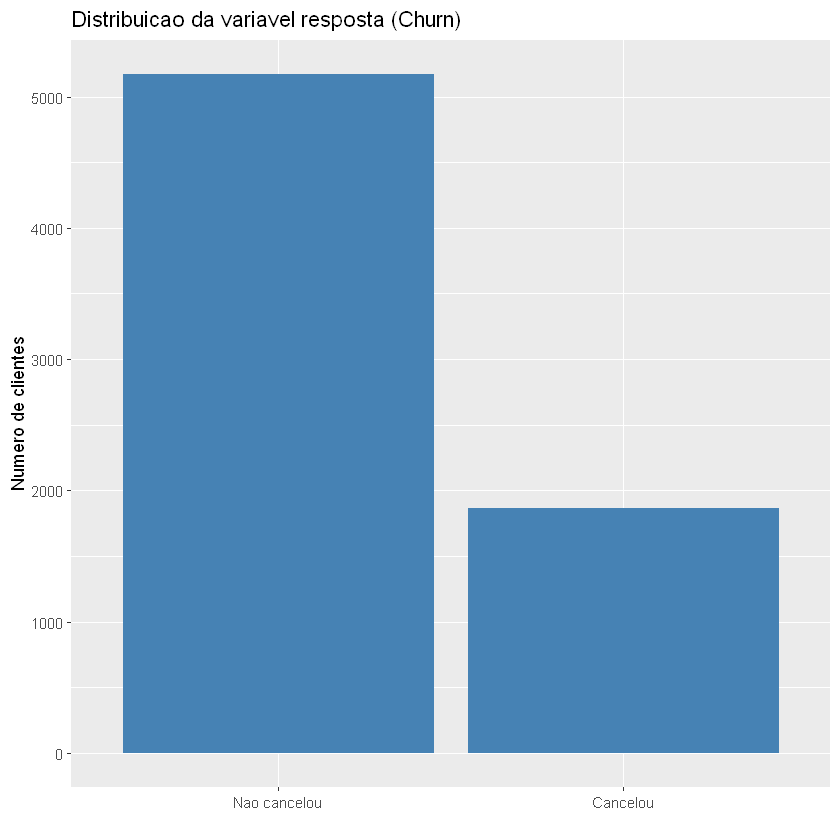

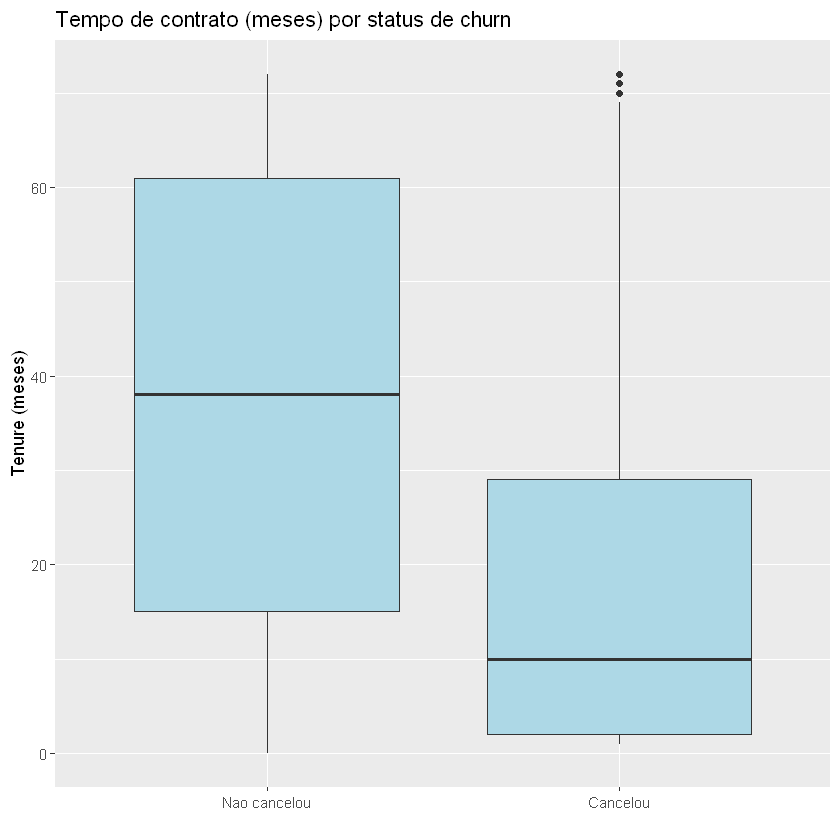

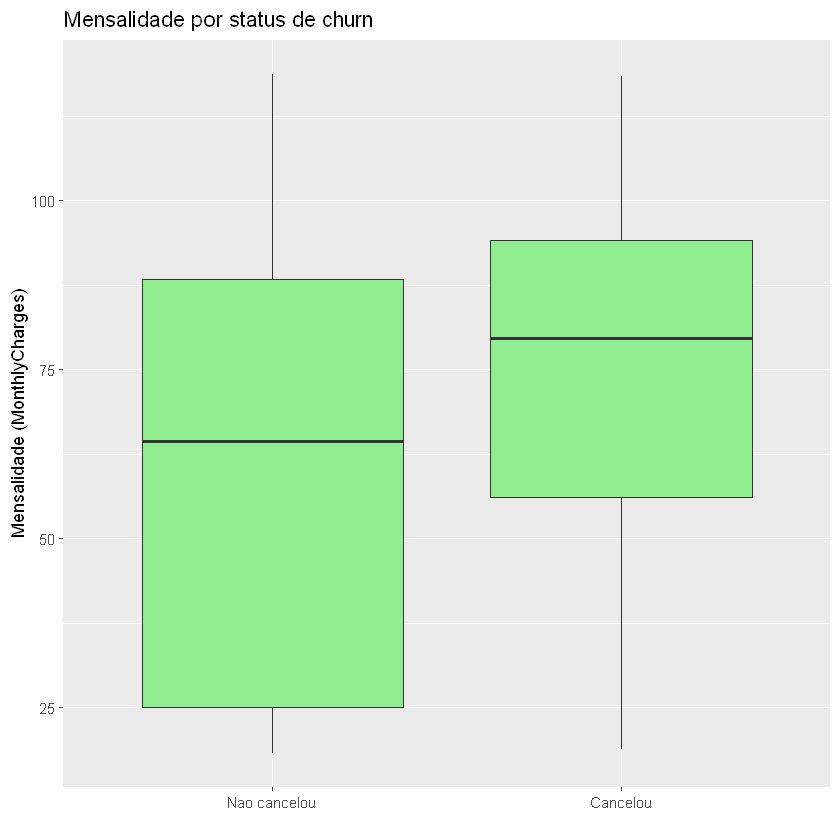

In [8]:
# Exploratória:

# grafico de barras mostrando a proporcao de clientes que
# cancelaram (1)e que nao cancelaram (0) o servico.
ggplot(dados, aes(x = factor(Churn, labels = c("Nao cancelou", "Cancelou")))) +
  geom_bar(fill = "steelblue") +
  labs(title = "Distribuicao da variavel resposta (Churn)",
       x = "", y = "Numero de clientes")


# Resumo estatistico (minimo, maximo, media, quartis) das tres
# variaveis numericas do banco.
summary(dados[, c("tenure", "MonthlyCharges", "TotalCharges")])

# Boxplot comparando a distribuicao do tempo de contrato (tenure)
# entre quem cancelou e quem nao cancelou. O que faz sentido éque
# clientes mais antigos cancelem menos.
ggplot(dados, aes(x = factor(Churn, labels = c("Nao cancelou", "Cancelou")),
                  y = tenure)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Tempo de contrato (meses) por status de churn",
       x = "", y = "Tenure (meses)")

# Boxplot comparando o valor da mensalidade entre quem cancelou e
# quem nao cancelou. Indica que as mensalidades mais altas
# estejam associadas a maior chance de cancelamento.
ggplot(dados, aes(x = factor(Churn, labels = c("Nao cancelou", "Cancelou")),
                  y = MonthlyCharges)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "Mensalidade por status de churn",
       x = "", y = "Mensalidade (MonthlyCharges)")
